# Customer Churn Prediction - Exploratory Data Analysis

#### Life cycle of Machine learning Project
1) Understanding the Problem Statement
2) Data Collection
3) Data Checks to perform
4) Exploratory data analysis
5) Data Pre-Processing
6) Model Training
7) Choose best model

### 1) Problem Statement

##### To understand how various customer attributes such as demographics, subscribed services, contract type, and billing information influence the likelihood of customer churn in a telecom company, and to identify key factors that predict whether a customer will leave the service

### 2) Data Collection

#####  Dataset Source -  https://www.kaggle.com/datasets/blastchar/telco-customer-churn

#####  This dataset consist of 21  columns and 7043 rows 

#### 2.1 Import Data and Required Packages

##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

##### Import the CSV Data as Pandas DataFrame

In [2]:
df=pd.read_csv("Data/Telco Customer Churn Dataset.csv")

##### Show Top 5 Records

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##### Shape of the Dataset

In [4]:
df.shape

(7043, 21)

#### 2.2) Dataset information

##### 
- **customerID** : unique identifier for each customer
- **gender** : sex of the customer -> (Male/Female)
- **SeniorCitizen** : whether the customer is a senior citizen -> (0/1)
- **Partner** : whether the customer has a partner -> (Yes/No)
- **Dependents** : whether the customer has dependents -> (Yes/No)
- **tenure** : number of months the customer has been with the company
- **PhoneService** : whether the customer has phone service -> (Yes/No)
- **MultipleLines** : whether the customer has multiple lines -> (Yes/No/No phone service)
- **InternetService** : type of internet service -> (DSL/Fiber optic/No)
- **OnlineSecurity** : whether the customer has online security -> (Yes/No/No internet service)
- **OnlineBackup** : whether the customer has online backup -> (Yes/No/No internet service)
- **DeviceProtection** : whether the customer has device protection -> (Yes/No/No internet service)
- **TechSupport** : whether the customer has tech support -> (Yes/No/No internet service)
- **StreamingTV** : whether the customer streams TV -> (Yes/No/No internet service)
- **StreamingMovies** : whether the customer streams movies -> (Yes/No/No internet service)
- **Contract** : type of contract -> (Month-to-month/One year/Two year)
- **PaperlessBilling** : whether the customer has paperless billing -> (Yes/No)
- **PaymentMethod** : payment method -> (Electronic check/Mailed check/Bank transfer/Credit card)
- **MonthlyCharges** : amount charged to the customer monthly
- **TotalCharges** : total amount charged to the customer
- **Churn** : whether the customer churned -> (Yes/No) ← target variable

### 3. Data Checks to perform
- Check Missing values 
- Check Duplicates 
- Check data type 
- Check the number of unique values of each column 
- Check statistics of data set 
- Check various categories present in the different categorical column 


#### 3.1 Check Missing values

In [5]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

##### There are no missing values in the data set

#### 3.2 Check Duplicates

In [6]:
print(df.duplicated().sum())

0


##### There are no duplicates values in the data set

#### 3.3 Check data types

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### 3.4 Checking the number of unique values of each column

In [8]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

#### 3.5 Check statistics of data set

In [9]:
#  converting TotalCharges to numeric for analysis
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


#### Insights

- Only 16.2% of customers are senior citizens, meaning the dataset is mostly non-senior customers
- Average tenure is 32 months, meaning customers stay for about 2.7 years on average
- Tenure ranges from 0 to 72 months, showing a mix of brand new and very loyal customers
- Average monthly charge is 64.76 with a wide std of 30.09, meaning pricing varies significantly across customers
- TotalCharges has only 7032 non-null values vs 7043 rows, confirming 11 missing values introduced after dtype conversion — will be handled in preprocessing
- TotalCharges ranges from 18.8 to 8684.8, which makes sense as it depends on both tenure and monthly charges

#### 3.6 Exploring Data

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
lis=df.select_dtypes(exclude="number").columns
lis_num=df.select_dtypes(include="number").columns
cat_features=list(lis)
num_features=list(lis_num)

In [12]:
print('We have {} numerical features : {}'.format(len(num_features), num_features))
print('\nWe have {} categorical features : {}'.format(len(cat_features), cat_features))

We have 4 numerical features : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

We have 17 categorical features : ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [13]:
# print(cat_features)
for i in cat_features:
    print(f"Categories in {i} Feature :",df[i].unique())
    print()

Categories in customerID Feature : ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

Categories in gender Feature : ['Female' 'Male']

Categories in Partner Feature : ['Yes' 'No']

Categories in Dependents Feature : ['No' 'Yes']

Categories in PhoneService Feature : ['No' 'Yes']

Categories in MultipleLines Feature : ['No phone service' 'No' 'Yes']

Categories in InternetService Feature : ['DSL' 'Fiber optic' 'No']

Categories in OnlineSecurity Feature : ['No' 'Yes' 'No internet service']

Categories in OnlineBackup Feature : ['Yes' 'No' 'No internet service']

Categories in DeviceProtection Feature : ['No' 'Yes' 'No internet service']

Categories in TechSupport Feature : ['No' 'Yes' 'No internet service']

Categories in StreamingTV Feature : ['No' 'Yes' 'No internet service']

Categories in StreamingMovies Feature : ['No' 'Yes' 'No internet service']

Categories in Contract Feature : ['Month-to-month' 'One year' 'Two year']

Categories in PaperlessB

#### 3.8 Adding columns "num_services",'avg_monthly_spend','tenure_group','high_spender'

In [14]:
services = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_services'] = (df[services] == 'Yes').sum(axis=1)

In [15]:
df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'] + 1)

In [16]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], 
                             labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

In [17]:
df['high_spender'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

In [18]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,num_services,avg_monthly_spend,tenure_group,high_spender
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,14.925000,0-1yr,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,3,53.985714,2-4yr,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3,36.050000,0-1yr,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,3,40.016304,2-4yr,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,50.550000,0-1yr,1


### 4. Exploring Data ( Visualization )

#### 4.1 Visualize Customer churn disturibution to make some conclusion

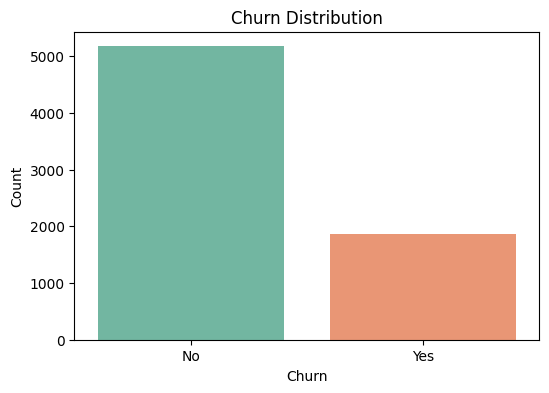

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

- The dataset is imbalanced with 73.2% customers not churned and 26.8% churned
- This imbalance will need to be handled during model training using techniques like class weights or SMOTE

#### 4.2 Does tenure affect Customer Churn 

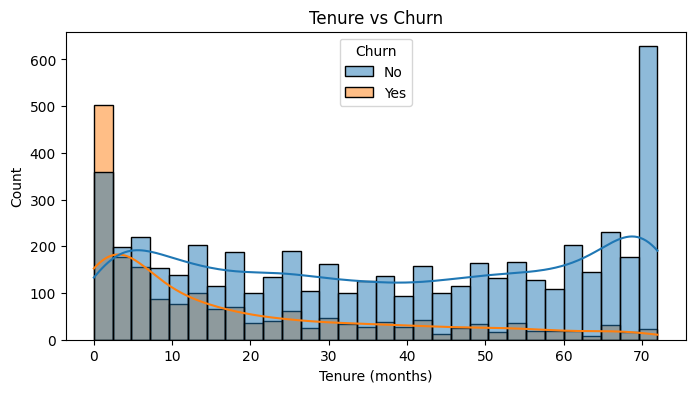

In [20]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure vs Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.show()

- Customers with low tenure (0-5 months) have the highest churn rate
- As tenure increases, churn decreases significantly
- Long term customers (60+ months) are highly loyal and rarely churn
- Tenure is likely to be a strong predictor for the model

#### 4.3 Feature vs Target analysis

In [21]:
numerical_features = ['MonthlyCharges', 'TotalCharges']
demographic_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
service_features = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity','OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
account_features = ['Contract', 'PaperlessBilling', 'PaymentMethod']
engineered_features = ['num_services', 'tenure_group', 'avg_monthly_spend', 'high_spender']

##### 4.3.1 how does numerical features influence target feature (Churn)

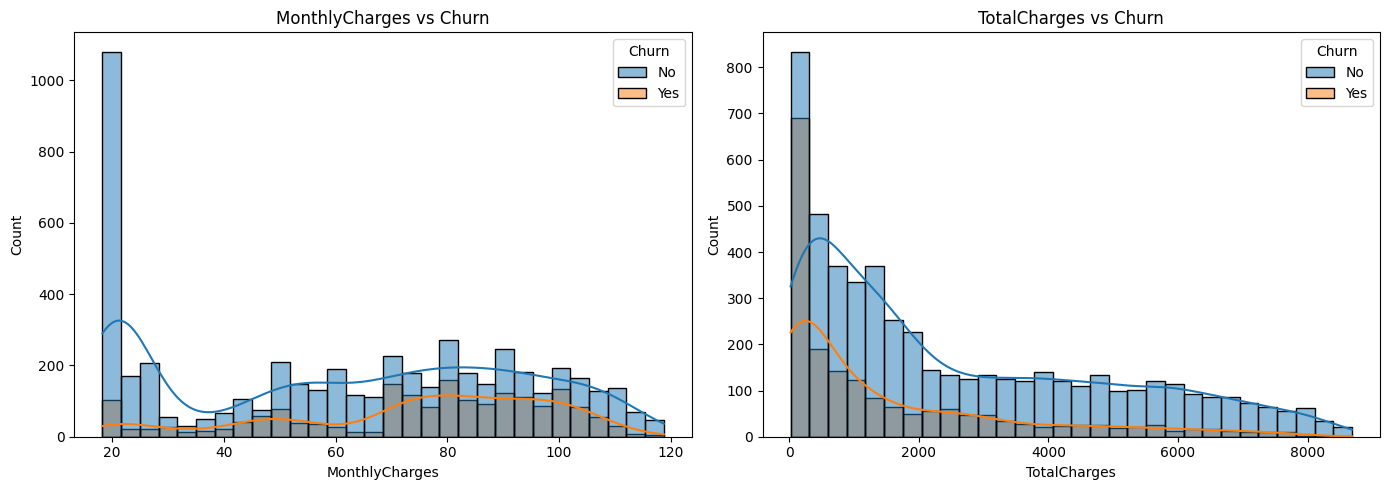

In [22]:
plt.figure(figsize=(14, 5))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, 2, i+1)
    sns.histplot(data=df, x=feature, hue='Churn', kde=True, bins=30)
    plt.title(f'{feature} vs Churn')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

- Customers with higher MonthlyCharges (60-120) are more likely to churn
- Customers with low TotalCharges churn the most — these are likely new customers who left early
- Customers with high TotalCharges rarely churn — indicating long term loyal customers
- MonthlyCharges and TotalCharges are both likely strong predictors of churn

##### 4.3.2 how does demographic features influence Churn

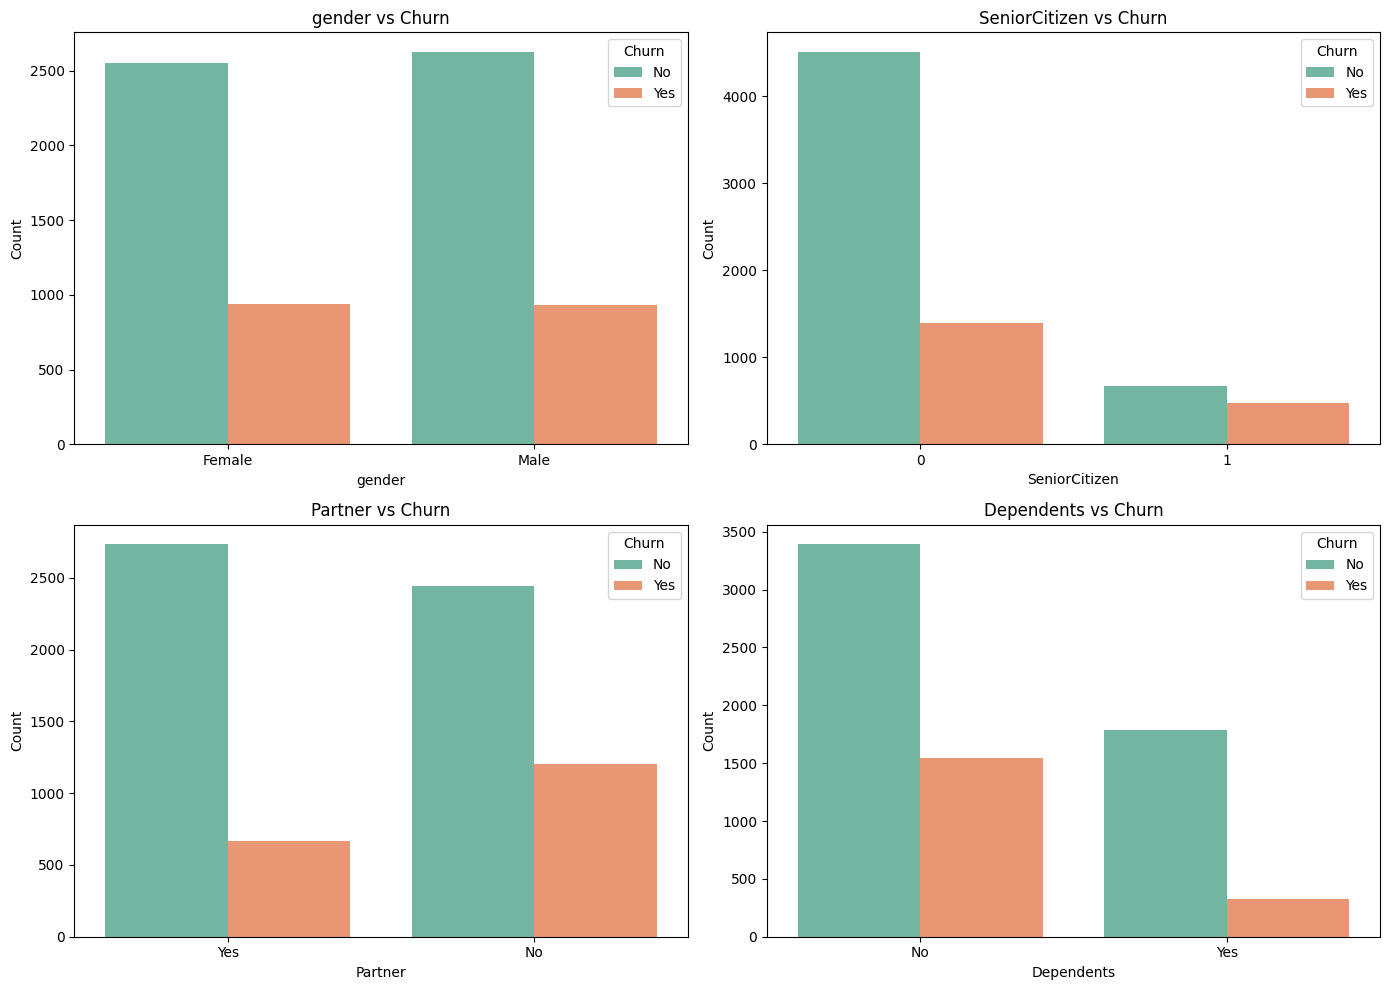

In [23]:
plt.figure(figsize=(14, 10))
for i, feature in enumerate(demographic_features):
    plt.subplot(2, 2, i+1)
    sns.countplot(data=df, x=feature, hue='Churn', palette='Set2')
    plt.title(f'{feature} vs Churn')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

- Gender has no significant effect on churn — nearly identical churn rates for male and female
- Senior citizens have a proportionally higher churn rate despite being a smaller group
- Customers without a partner churn more — possibly less invested in shared services
- Customers with dependents are significantly less likely to churn — family responsibility reduces switching behavior

##### 4.3.3 how does service features influence Churn

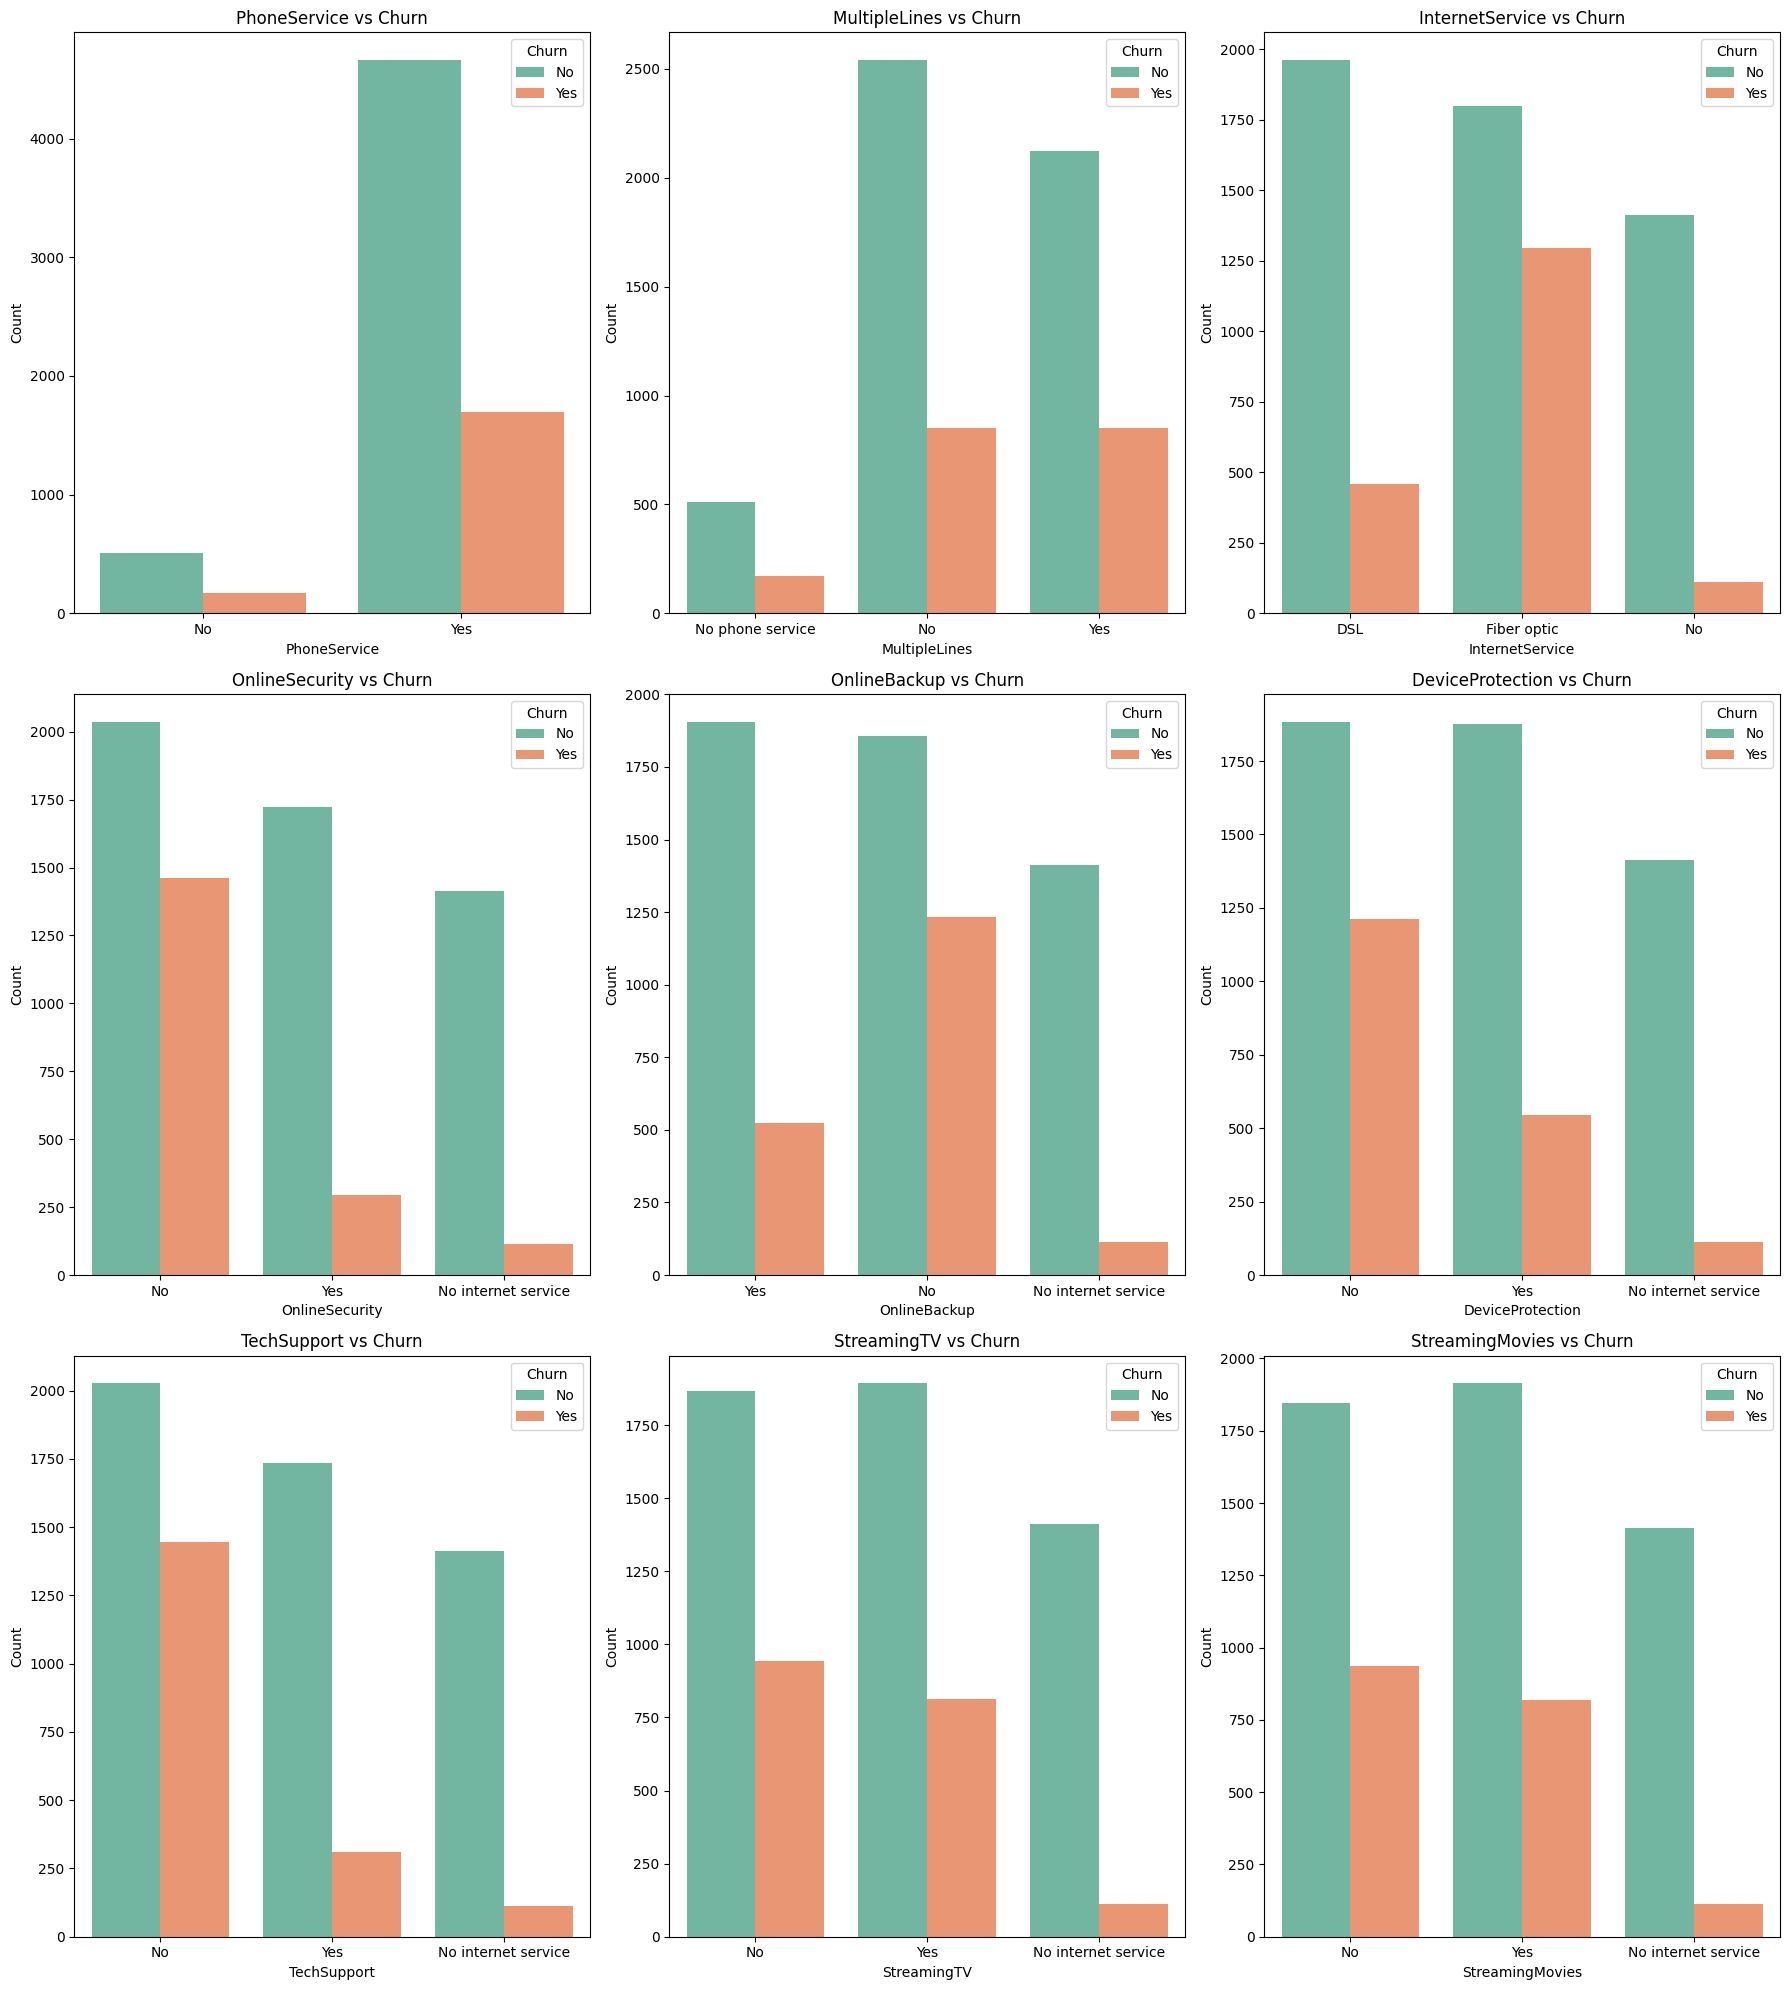

In [24]:
plt.figure(figsize=(18, 20))
for i, feature in enumerate(service_features):
    plt.subplot(3, 3, i+1)
    sns.countplot(data=df, x=feature, hue='Churn', palette='Set2')
    plt.title(f'{feature} vs Churn')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

- Fiber optic internet users churn the most — possibly due to higher costs or competition
- Customers without OnlineSecurity, TechSupport, OnlineBackup and DeviceProtection churn significantly more
- Streaming services (TV and Movies) have little effect on churn
- PhoneService and MultipleLines are weak predictors of churn
- InternetService type is likely one of the strongest predictors

##### 4.3.4 how does account features influence Churn

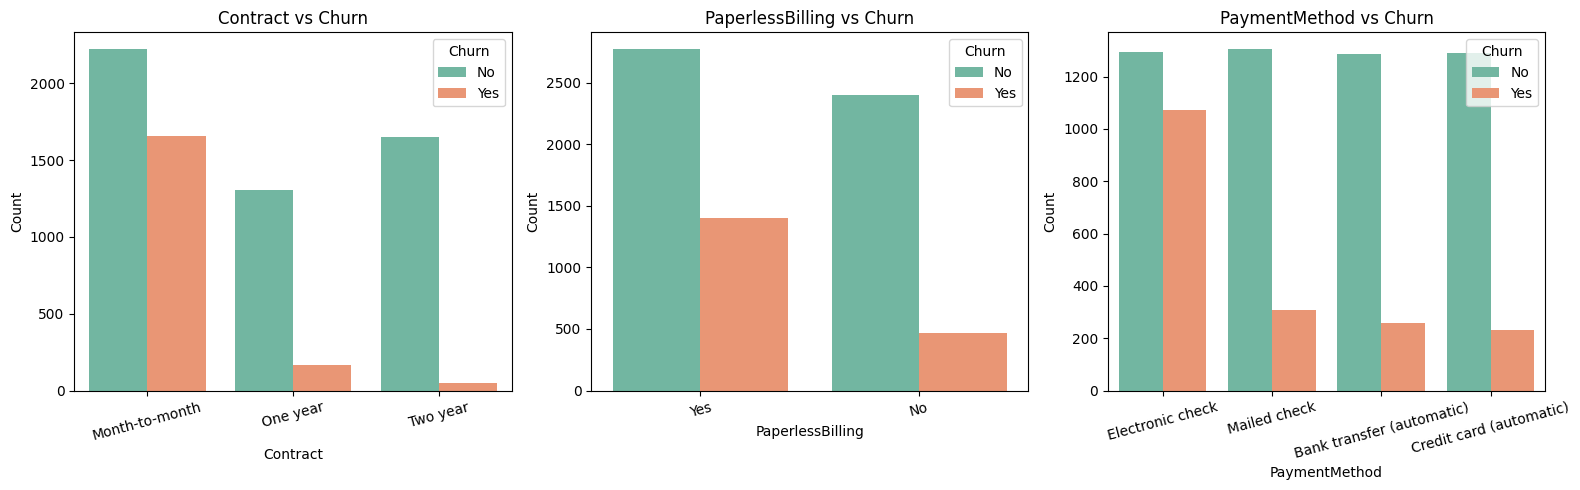

In [25]:
plt.figure(figsize=(16, 5))
for i, feature in enumerate(account_features):
    plt.subplot(1, 3, i+1)
    sns.countplot(data=df, x=feature, hue='Churn', palette='Set2')
    plt.title(f'{feature} vs Churn')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

- Month-to-month contract customers churn at an alarming rate — contract type is likely the strongest predictor of churn
- Two year contract customers almost never churn — long term commitment strongly reduces churn
- Paperless billing customers churn more — possibly more digitally active and likely to compare competitors
- Electronic check payment users have the highest churn rate among all payment methods
- Mailed check, bank transfer and credit card users show similar and much lower churn rates

##### 4.3.5 how does engineered features influence Churn

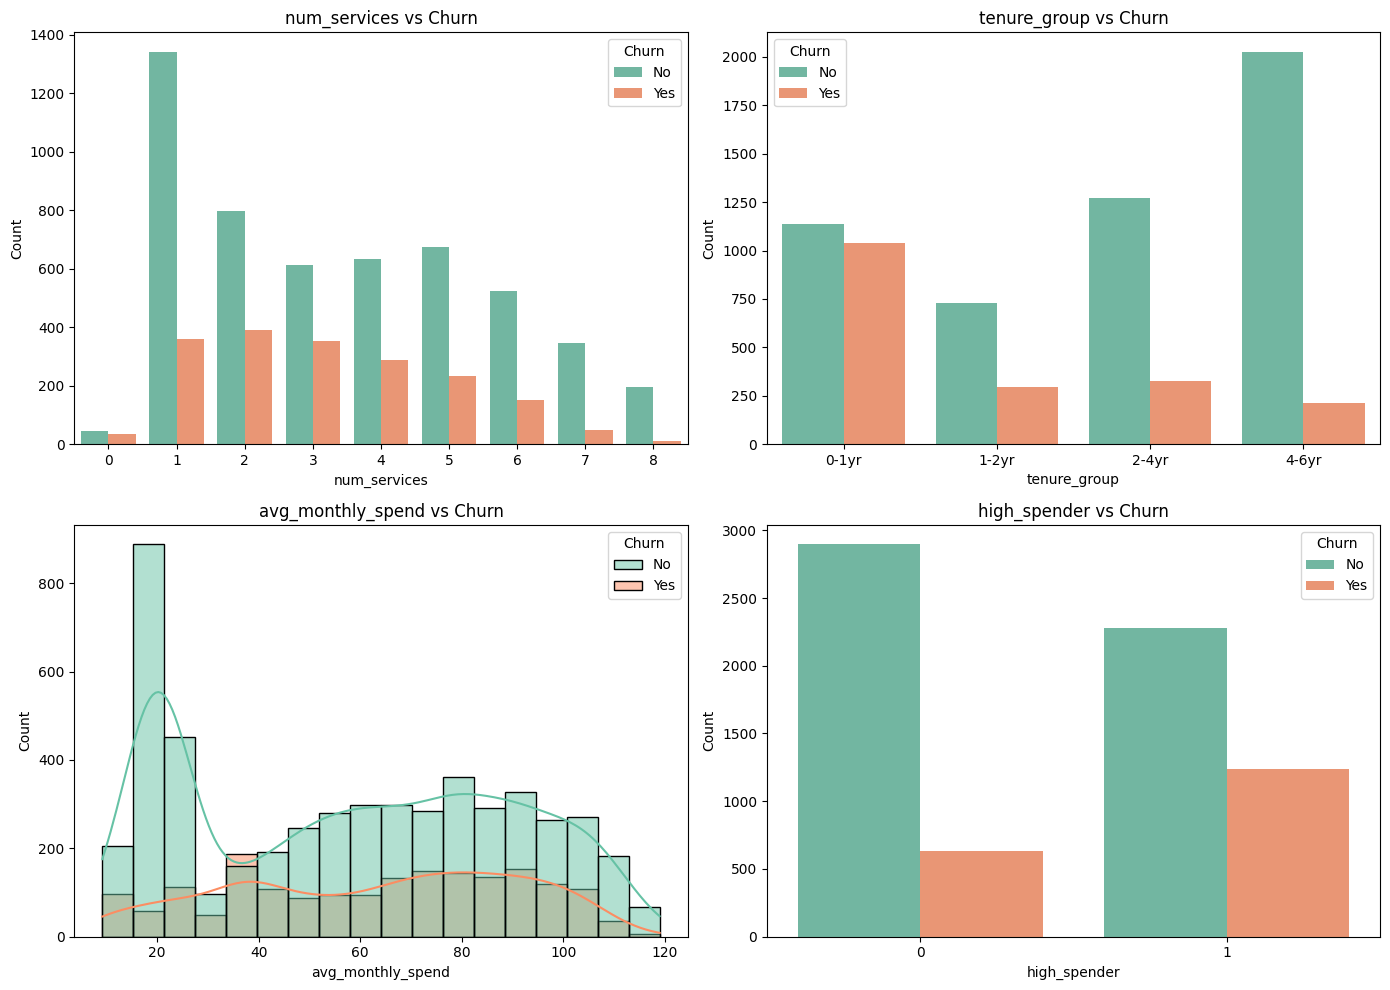

In [26]:
plt.figure(figsize=(14, 10))
for i, feature in enumerate(engineered_features):
    plt.subplot(2, 2, i+1)
    if feature in ['avg_monthly_spend']:
        sns.histplot(data=df, x=feature, hue='Churn', kde=True, palette='Set2')
    else:
        sns.countplot(data=df, x=feature, hue='Churn', palette='Set2')
    plt.title(f'{feature} vs Churn')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

- Customers with more services churn less — more services create more value and switching cost
- Tenure group strongly confirms churn pattern — new customers (0-1yr) are at highest risk
- High spenders churn more proportionally — likely fiber optic and month-to-month customers
- avg_monthly_spend does not show a clear churn pattern — may not be a useful feature for the model

#### Contract vs InternetService churn rate heatmap

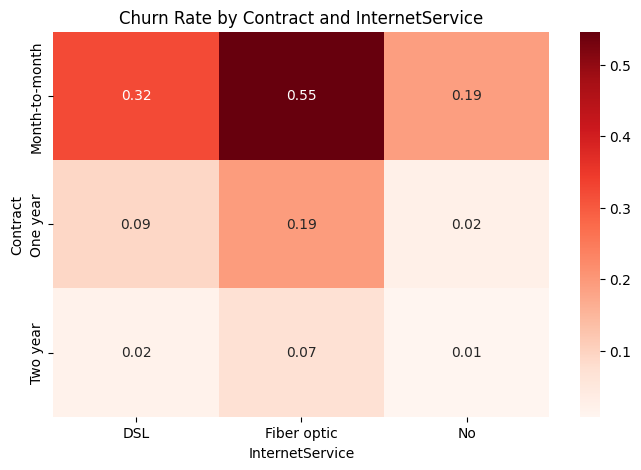

In [27]:
pivot = df.groupby(['Contract', 'InternetService'])['Churn'].apply(lambda x: (x=='Yes').mean()).unstack()
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Reds')
plt.title('Churn Rate by Contract and InternetService')
plt.show()

- Month-to-month Fiber optic customers have the highest churn rate at 55% — the most at risk segment
- Switching from month-to-month to a two year contract reduces fiber optic churn from 55% to just 7%
- Two year contract customers have extremely low churn regardless of internet service type
- Contract type has a stronger influence on churn than internet service type

#### 4.3.6 Correlation Heatmap 

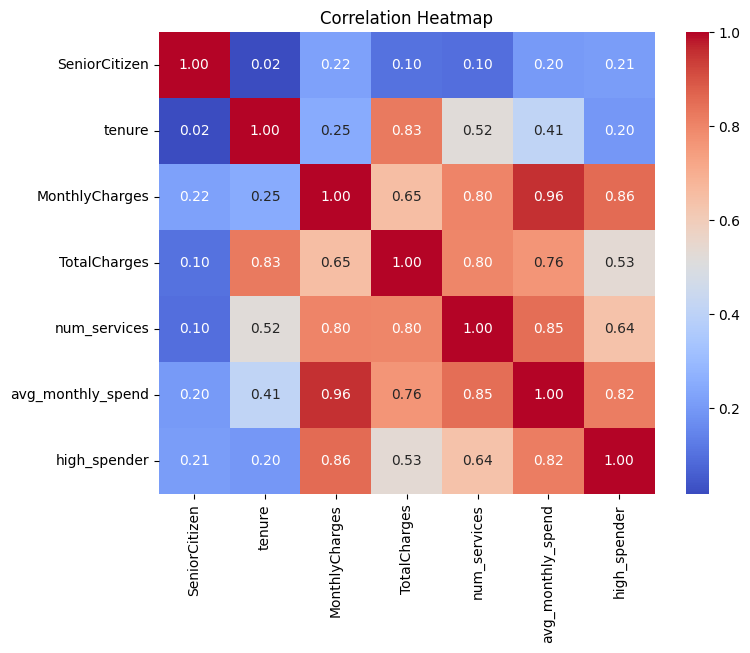

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 
                'num_services', 'avg_monthly_spend', 'high_spender']].corr(), 
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

- tenure and TotalCharges are highly correlated (0.83) — longer tenure leads to higher total charges
- avg_monthly_spend is almost identical to MonthlyCharges (0.96) — may be dropped before modeling
- num_services correlates strongly with MonthlyCharges (0.80) — more services means higher bills
- SeniorCitizen has very weak correlation with all features — weak predictor

### Outlier Analysis

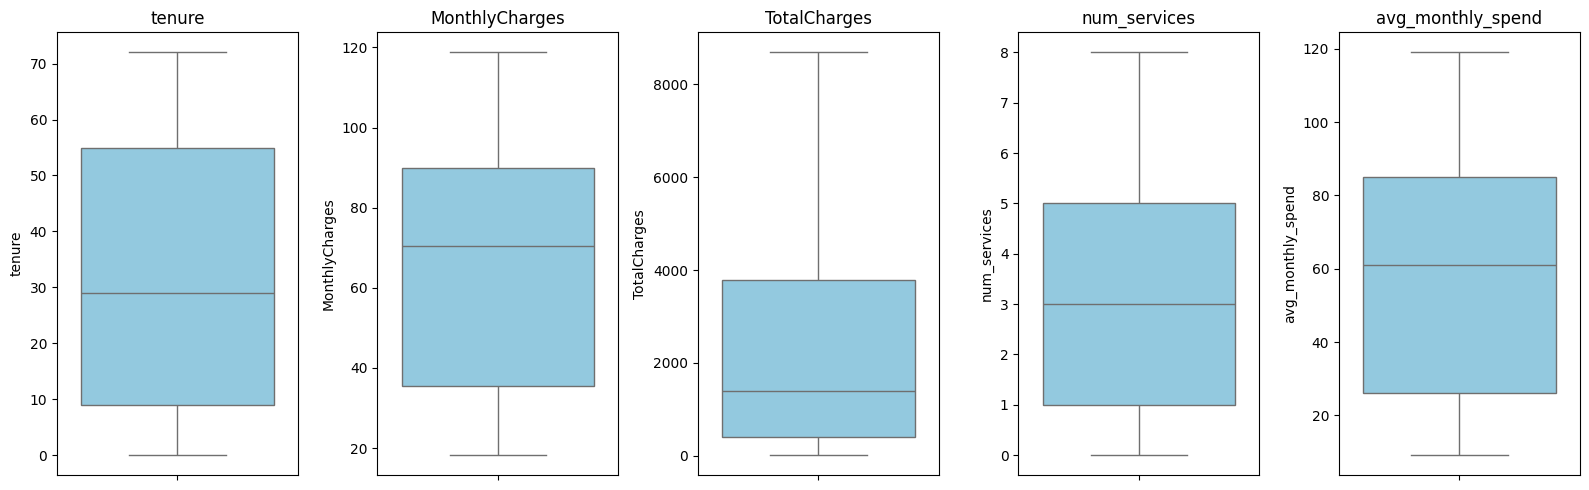

In [29]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services', 'avg_monthly_spend']

plt.figure(figsize=(16, 5))
for i, feature in enumerate(numerical_cols):
    plt.subplot(1, 5, i+1)
    sns.boxplot(y=df[feature], color='skyblue')
    plt.title(feature)
plt.tight_layout()
plt.show()

- No outliers detected in any numerical feature
- All features have naturally bounded ranges due to the nature of telecom pricing and service subscriptions
- Data does not require outlier treatment before modeling

## Overall EDA Summary — Key Findings

### Target Variable
- Dataset is imbalanced — 73.2% No churn, 26.8% Yes churn
- Class imbalance will need to be handled during model training

### Strongest Predictors of Churn
- **Contract type** — month-to-month customers churn the most, two year customers are highly loyal
- **Internet Service** — fiber optic customers have the highest churn rate
- **Tenure** — new customers (0-1yr) are at highest risk, long term customers rarely churn
- **MonthlyCharges** — higher paying customers churn more
- **OnlineSecurity and TechSupport** — customers without these services churn significantly more

### Customer Segments Most at Risk
- Month-to-month + Fiber optic customers — 55% churn rate, highest risk segment
- New customers with low tenure (0-5 months)
- Customers without online security, tech support or device protection
- Electronic check payment users
- Customers without partners or dependents

### Features Likely Less Useful for Modeling
- Gender — no significant difference in churn between male and female
- avg_monthly_spend — highly correlated with MonthlyCharges (0.96), redundant
- SeniorCitizen — weak correlation with all features

### Data Quality
- No duplicate values found
- 11 missing values in TotalCharges after dtype conversion — to be handled in preprocessing
- TotalCharges dtype needs to be converted from object to float64 in preprocessing
- No outliers detected in any numerical feature